In [1]:
import time
from functools import partial
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import pickle
import jax.numpy as jnp
import jax
import jax.random as jr
import numpy as onp
import jax.flatten_util
import pandas as pd
import optax
import jaxopt
from flax.training import train_state
import scipy
from neuralss import ss_init, ss_apply
from ae import VAE_Encoder, Projector
import nonlinear_benchmarks
from matplotlib import pyplot as plt
tex_fonts = {
    # Use LaTeX to write all text
   "text.usetex": True,
   "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
#    "axes.labelsize": 14,
#    "font.size": 14,
#    "legend.fontsize": 12,
#    "xtick.labelsize": 12,
#    "ytick.labelsize": 12
}
plt.rcParams.update(tex_fonts)

In [2]:
key = jr.key(42)

Jax plugin configuration error: Plugin module jax_plugins.xla_cuda12 does not exist
CUDA backend failed to initialize: jaxlib/cuda/versions_helpers.cc:98: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
jax.config.update("jax_default_device", jax.devices("cpu")[0])

RuntimeError: Unknown backend: 'gpu' requested, but no platforms that are instances of gpu are present. Platforms present are: cpu

In [ ]:
MAX_BETA = 0.1
ckpt_path = Path("out") /f"vae_{str(MAX_BETA).replace('.', '_')}.p"
# ckpt_path = Path("tmp") / f"vae_145000.p"
ckpt = pickle.load(open(ckpt_path, "rb"))

fig_dir = Path("fig")
fig_dir.mkdir(exist_ok=True)
cfg = ckpt["cfg"]
params_enc, params_proj, params_ss,log_sigma_est = ckpt["params"]
sigma_est = jnp.exp(log_sigma_est)
scalers = ckpt["scalers"]
params_dec_flat, unflatten_dec = jax.flatten_util.ravel_pytree(params_ss)
n_params = params_dec_flat.shape[0]

In [ ]:
train_lens = [100]#, 200, 300, 400, 500, 600, 700, 800, 900, 1_000, 2000, 3000, 4000, 5000]
mc_size = 100

In [ ]:
data_folder = "bwdataset"
data_folder = Path(data_folder)
data = scipy.io.loadmat(data_folder / "bw_matlab.mat")

y_train = data["y"] / 7e-4
u_train = data["u"] / 50.0

y_test = scipy.io.loadmat(data_folder / "yval_multisine.mat")["yval_multisine"].reshape(-1, 1) / 7e-4
u_test = scipy.io.loadmat(data_folder / "uval_multisine.mat")["uval_multisine"].reshape(-1, 1) / 50.0
N = y_train.shape[0]

In [4]:
enc = VAE_Encoder(mlp_layers=[cfg.nh, cfg.nz], rnn_size=cfg.nh)
proj = Projector(outputs=n_params,  unflatten=unflatten_dec)

NameError: name 'cfg' is not defined

In [5]:
def loss_reduced(ov, y, u):
    
    # Project the latent into parameters of the decoder
    pe = proj.apply(params_proj, ov["z"])

    # Use in the decoder output to define/update the model parameters
    pa = jax.tree.map(lambda x, y: x+y, params_ss, pe)
    
    y_hat = ss_apply(pa, scalers, ov["x0"], u)
    #scaled_err = (y1 - y1_hat) / ckpt["sigma_noise"]
    #loss = jnp.sum(scaled_err**2) + jnp.sum(ov["z"]**2)
    loss = jnp.mean((y - y_hat)**2)/((sigma_est+1e-6) ** 2)+ 0.1*jnp.sum(ov["z"]**2)
#     loss = jnp.mean((y - y_hat)**2)
    return loss

def train_reduced(ov, y, u, iters=10_000, lr=1e-3):

        loss_cfg = partial(loss_reduced, y=y, u=u)
        opt = optax.adamw(learning_rate=lr)
        state = train_state.TrainState.create(apply_fn=loss_cfg, params=ov, tx=opt)

        @jax.jit
        def make_step(state):
                loss, grads = jax.value_and_grad(state.apply_fn)(state.params)
                state = state.apply_gradients(grads=grads)
                return loss, state
        
        losses = jnp.empty(iters)
        for idx in (pbar := tqdm(range(iters))):
                loss, state = make_step(state)
                losses = losses.at[idx].set(loss)
                #pbar.set_postfix_str(loss.item())

        return state.params, jnp.array(losses)

def loss_for_hessian(z, x0, y, u):
    ov = {"z": z, "x0": x0}
    return loss_reduced(ov, y, u)

batched_hessian_fn = jax.vmap(jax.hessian(loss_for_hessian, argnums=0), in_axes=(0, 0, 0, 0))

# --- 2. Predictive Uncertainty Sampling Function ---
num_post_samples = 50 # Number of samples to draw from the Laplace posterior

def get_predictive_std(z_mean, cov, key,u_test):
    # Sample z ~ N(z_mean, cov)
    z_samples = jax.random.multivariate_normal(key, mean=z_mean, cov=cov, shape=(num_post_samples,))
    
    # Map the z samples to state-space parameters
    p_ss_proj = jax.vmap(proj.apply, in_axes=(None, 0))(params_proj, z_samples)
    p_red_samples = jax.vmap(lambda p: jax.tree_util.tree_map(lambda x, y: x+y, params_ss, p))(p_ss_proj)
    
    # Simulate forward to get predictions for all samples
    x0_test = jnp.zeros((cfg.nx, ))
    y_samples = jax.vmap(ss_apply, in_axes=(0, None, None, None))(p_red_samples, scalers, x0_test, u_test)
    y_mean = jnp.mean(y_samples, axis=0) # shape: (seq_len, ny)
    y_std = jnp.std(y_samples, axis=0)   # shape: (seq_len, ny)
    
    return y_mean.squeeze(-1), y_std.squeeze(-1)
    # lower_bound = jnp.percentile(y_samples, 2.5, axis=0)
    # upper_bound = jnp.percentile(y_samples, 97.5, axis=0)
    # robust_std = (upper_bound - lower_bound) / 4.0
    
    # # Calculate std across the 30 samples, then average over time and output dimensions
    # # Returns a single scalar representing the predictive uncertainty!
    # return jnp.mean(robust_std)

# Vectorize over the MC dimension
batched_get_pred_trajectories = jax.jit(jax.vmap(get_predictive_std, in_axes=(0, 0, 0, None)))


In [6]:
fit_red = onp.empty((len(train_lens), mc_size))
train_time = onp.empty(len(train_lens))

pred_std_red = onp.empty((len(train_lens), mc_size)) 
latent_std_red = onp.empty((len(train_lens), mc_size))


NameError: name 'train_lens' is not defined

In [7]:
# ==========================================
# Initialize lists to store metrics for the final plot
# ==========================================
all_coverage_3sigma = []
all_mean_epistemic_stds = []
aleatoric_std = float(sigma_est) # This is constant, just keeping a clean scalar copy

# train mc_size models in parallel!
for len_idx, train_len in enumerate(train_lens):

    print(f"Processing length {train_len}...")
    
    time_start = time.time()
    # generate mc sequences
    key, subkey = jr.split(key)     
    start_indexes = jr.randint(subkey, shape=(mc_size,),  minval=0, maxval=N-train_len)
    mc_indexes = start_indexes[:, None] + jnp.arange(train_len)
    mc_y, mc_u = y_train[mc_indexes], u_train[mc_indexes]

    print(f"Training {mc_size} reduced models...")
    # train reduced models
    z_init = jnp.zeros((mc_size, cfg.nz, ))
    z_init,_ = jax.vmap(enc.apply, in_axes=(None, 0, 0))(params_enc, mc_y, mc_u)
    opt_vars_red_init = {"z": z_init, "x0": jnp.zeros((mc_size, cfg.nx, ))}
    pe = jax.vmap(proj.apply, in_axes=(None, 0))(params_proj, opt_vars_red_init["z"])

    # Use in the decoder output to define/update the model parameters
    pa = jax.tree.map(lambda x, y: x+y, params_ss, pe)

    x0 = jnp.zeros((cfg.nx, ))
    y_hat = jax.vmap(ss_apply, in_axes=(0,None, 0, 0))(pa, scalers, opt_vars_red_init["x0"], mc_u)
    y_test_hat = jax.vmap(ss_apply, in_axes=(0,None, None, None))(pa, scalers, x0, u_test)
    print(jnp.mean(jnp.sqrt(jnp.mean((y_hat - mc_y)**2, axis=(1, 2)))),jnp.mean(jnp.sqrt(jnp.mean((y_test_hat - y_test)**2, axis=(1, 2)))))
    
    opt_vars_red, losses_red = jax.vmap(train_reduced, in_axes=(0, 0, 0))(opt_vars_red_init, mc_y, mc_u)

    # project trained zetas to the ss parameter space
    params_ss_proj = jax.vmap(proj.apply, in_axes=(None, 0))(params_proj, opt_vars_red["z"])
    params_red = jax.tree.map(lambda x, y: x+y, params_ss, params_ss_proj)

    train_time[len_idx] = time.time() - time_start
    
    hessians = batched_hessian_fn(opt_vars_red["z"], opt_vars_red["x0"], mc_y, mc_u)*train_len
    jitter = 1e-4 * jnp.eye(cfg.nz)
    hessians_stable = hessians + jitter[None, :, :]
    
    # Directly invert the batched Hessians
    posterior_covariances = jax.vmap(jnp.linalg.inv)(hessians_stable)
    
    # Force mathematical symmetry to prevent downstream Cholesky errors
    posterior_covariances = 0.5 * (posterior_covariances + jax.vmap(jnp.transpose)(posterior_covariances))

    # 2. (Optional) Store the average latent std
    variances = jax.vmap(jnp.diag)(posterior_covariances)
    stds = jnp.sqrt(jnp.abs(variances))
    latent_std_red[len_idx, :] = onp.array(jnp.mean(stds, axis=-1)) # Shape: (mc_size,)
    
    # 3. Compute the Predictive Std using the sampling function
    key, subkey = jr.split(key)
    keys = jax.random.split(subkey, mc_size)
    _,mc_pred_stds = batched_get_pred_trajectories(opt_vars_red["z"], posterior_covariances, keys, u_test)
    print(mc_pred_stds.mean())
    pred_std_red[len_idx, :] = onp.array(mc_pred_stds.mean(axis = 1)) # Shape: (mc_size,)
    
    # test reduced models
    x0 = jnp.zeros((cfg.nx, ))
    y_hat = jax.vmap(ss_apply, in_axes=(0, None, 0, 0))(params_red, scalers, opt_vars_red["x0"], mc_u)
    y_test_hat = jax.vmap(ss_apply, in_axes=(0, None, None, None))(params_red, scalers, x0, u_test)
    print(jnp.mean(jnp.sqrt(jnp.mean((y_hat - mc_y)**2, axis=(1, 2)))),jnp.mean(jnp.sqrt(jnp.mean((y_test_hat - y_test)**2, axis=(1, 2)))))

    for mc_idx in range(mc_size):
        fit_red[len_idx, mc_idx] = nonlinear_benchmarks.error_metrics.fit_index(y_test[cfg.skip_loss:], y_test_hat[mc_idx, cfg.skip_loss:])[0]
    print(f"Mean Fit for len={train_len}: {fit_red[len_idx, :].mean():.2f}%")
    
    # ==========================================
    # NEW: Calculate 3-Sigma Coverage on Test Set
    # ==========================================
    # Get mean prediction and std for the full test set
    key, subkey = jr.split(key)
    keys = jax.random.split(subkey, mc_size)
    mc_y_mean, mc_y_std = batched_get_pred_trajectories(opt_vars_red["z"], posterior_covariances, keys, u_test)
    
    # Use the mean trajectory and std from the first model (or average over all if preferred)
    idx_eval = 0
    y_mean_eval = mc_y_mean[idx_eval, cfg.skip_loss:]
    y_std_eval = mc_y_std[idx_eval, cfg.skip_loss:]
    y_true_eval = y_test[cfg.skip_loss:].squeeze(-1)
    
    # Calculate bounds using TOTAL uncertainty
    total_y_std_eval = jnp.sqrt(y_std_eval**2 + sigma_est**2)

    # Note: Using 3-sigma here for the array collection to match the final plot target!
    lower_bound = y_mean_eval - 3 * total_y_std_eval
    upper_bound = y_mean_eval + 3 * total_y_std_eval

    # Check where true value is inside bounds
    within_bounds = (y_true_eval >= lower_bound) & (y_true_eval <= upper_bound)
    coverage_percentage = jnp.mean(within_bounds) * 100.0
    
    print(f"3-Sigma Test Coverage for len={train_len}: {coverage_percentage:.2f}%")
    
    # APPEND TO OUR LISTS FOR THE FINAL CDC PLOT
    all_coverage_3sigma.append(coverage_percentage)
    all_mean_epistemic_stds.append(float(jnp.mean(y_std_eval)))
    # ==========================================

    if train_len == 100:
        # 2. Sample 10 latent vectors from the prior
        z_samples = onp.random.normal(size=(1, cfg.nz))
        params_ss_proj = jax.vmap(proj.apply, in_axes=(None, 0))(params_proj, z_samples)
        params_red_gen = jax.tree.map(lambda x, y: x+y, params_ss, params_ss_proj)

        # 3. Pass through the neural decoder using your batched function
        x0 = jnp.zeros((cfg.nx, ))
        ypred = jax.vmap(ss_apply, in_axes=(0, None, None, None))(params_red_gen, scalers, x0, u_test)

        # 4. Plot the results
        plt.figure(figsize=(10, 6))
        plt.plot(ypred.squeeze(-1).T)
        plt.title("Generated Prior Responses using Real Multisine Input")
        plt.xlabel("Time steps")
        plt.ylabel("Displacement")
        plt.savefig(f"vae_generated_reconstruction{MAX_BETA}.png")
        plt.show()

        u_ts = u_test[-1200:]  # Shape should be (1200, 1)

        # 1. Get the mean prediction and posterior standard deviation for your models!
        key, subkey = jr.split(key)
        keys = jax.random.split(subkey, mc_size)
        
        # Pass the full u_test here
        mc_y_mean, mc_y_std = batched_get_pred_trajectories(opt_vars_red["z"], posterior_covariances, keys, u_test)
        
        # 2. Select ONE model from your batch to plot (e.g. index 0)
        idx_to_plot = 0
        y_pred_mean = mc_y_mean[idx_to_plot]
        y_pred_std_total = jnp.sqrt(mc_y_std[idx_to_plot]**2 + sigma_est**2)
        y_true = y_test.squeeze(-1)
        
        y_test_hat_mean = y_test_hat.mean(axis=0).squeeze(-1)

        # 3. Slice a "zoom in" region so the multisine wave is readable
        plot_start = cfg.skip_loss
        plot_end = 1200  
        
        t_steps = jnp.arange(plot_start, plot_end)
        
        y_true_slice = y_true[plot_start:plot_end]
        y_mean_slice = y_pred_mean[plot_start:plot_end]
        y_std_slice = y_pred_std_total[plot_start:plot_end]
        y_test_hat_mean_slice = y_test_hat_mean[plot_start:plot_end]

        # 4. Plot True vs Predicted with 3-Sigma bounds
        plt.figure(figsize=(12, 6))
        plt.plot(t_steps, y_true_slice, label="True Dynamics", color="black", linewidth=2.0)
        plt.plot(t_steps, y_mean_slice, label="Posterior Mean Prediction", color="tab:blue", linestyle="--", linewidth=2.0)

        lower_bound = y_mean_slice - 3 * y_std_slice
        upper_bound = y_mean_slice + 3 * y_std_slice
        plt.fill_between(t_steps, lower_bound, upper_bound, color="tab:blue", alpha=0.3, label="3-$\sigma$ Total Uncertainty")

        plt.title(f"Test Set Prediction with Total Uncertainty (Train Len = {train_len})",fontsize=28)
        plt.xlabel("Time steps",fontsize=23)
        plt.ylabel("Displacement",fontsize=23)
        plt.legend(loc="upper right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.legend(fontsize = 23)
        plt.xticks(fontsize=23)
        plt.yticks(fontsize=23)
        plt.savefig(fig_dir/f"posterior_uncertainty_plot_len{train_len}_{MAX_BETA}.pdf")
        plt.show()


NameError: name 'sigma_est' is not defined

In [27]:
# all_coverage_3sigma = all_coverage_3sigma.append(99.7)
# print(all_coverage_3sigma)

None


ValueError: x and y must have same first dimension, but have shapes (14,) and (1,)

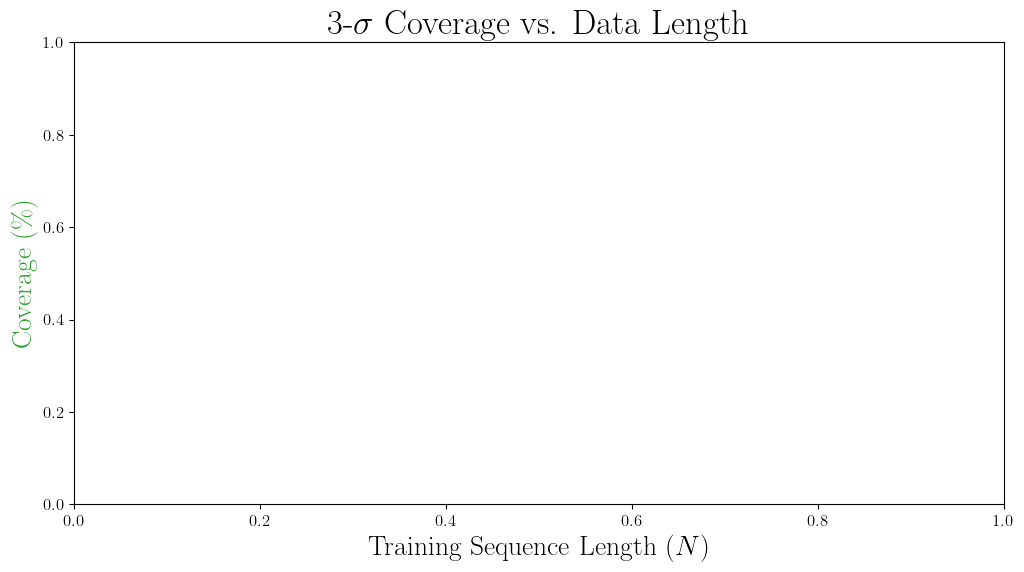

In [19]:

# ==========================================
# END OF LOOP. NOW GENERATE THE FINAL CDC PLOT
# ==========================================
import matplotlib.pyplot as plt
import numpy as onp

# Convert lists to numpy arrays for element-wise math
mean_epistemic_stds = onp.array(all_mean_epistemic_stds)
# Calculate the mean total std: Total = sqrt(Epistemic^2 + Aleatoric^2)
mean_total_stds = onp.sqrt(mean_epistemic_stds**2 + aleatoric_std**2)

# Create a figure with 2 vertically stacked subplots sharing the x-axis
# gridspec_kw allocates more height to the uncertainty plot (top) than coverage (bottom)
# fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True, 
                            #    gridspec_kw={'height_ratios': [2.5, 1]})
plt.figure(figsize=(12, 6))

# =============================================================================
# --- TOP AXIS (ax1): Uncertainty Width Decomposition ---
# =============================================================================
# ax1.set_ylabel('Mean $3\sigma$ Bound Width', fontsize=11)
plt.title('3-$\sigma$ Coverage vs. Data Length', fontsize=25)

plt.xlabel('Training Sequence Length ($N$)', fontsize=20)
plt.ylabel('Coverage (\%)', color='tab:green', fontsize=20)

# Plot 4: Coverage
plt.plot(train_lens, all_coverage_3sigma, label='Empirical Coverage', 
         color='tab:green', linewidth=2, marker='s')

# Add a reference line for perfect 3-sigma coverage (99.7%)
plt.axhline(99.7, color='tab:green', linestyle=':', alpha=0.6, label='Ideal Coverage 3-$\sigma$ (99.7\%)')

plt.tick_params(axis='y', labelcolor='tab:green')
plt.grid(True, alpha=0.3)

# Dynamically set y-limits for coverage so it looks nice
min_cov = min(all_coverage_3sigma)
plt.ylim([max(0, min_cov - 2), 101]) 
plt.legend(loc='lower right', fontsize=20)

# =============================================================================
# --- Final Formatting ---
# =============================================================================
plt.tight_layout() 
# Remove vertical whitespace between the two plots to keep it compact
# plt.subplots_adjust(hspace=0.08) 
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.savefig(fig_dir/"cdc_uncertainty_decomposition_clean.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# Save the final checkpoint
ckpt = {
    "train_lens": train_lens,
    "train_time": train_time,
    "fit": fit_red,
    "pred_std": pred_std_red,     # <--- Add this
    "latent_std": latent_std_red  # <--- Add this
}


ckpt_path = Path("out") / f"mc_red_VAE_{str(MAX_BETA).replace('.', '_')}.p"
ckpt_path.parent.mkdir(exist_ok=True, parents=True)
pickle.dump(ckpt, open(ckpt_path, "wb" ))